In [2]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import json
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [3]:
#Import custom functions
from oriseg_funcs import *

plt.close('all')
    
# Set Plotting Params
fcolor = 'white'#[.125, .125, .125]
lcolor = 'black'##[1., 1., 1.]
savefigs = False #True #if true save all figures
fig_format = 'svg'

# Set Paths
#mainDir = '/home/scat-raid3/data/oriSeg'
mainDir = '.'
figDir = mainDir+'/figs/'

# Set Multiple Comparisons Correction
statCorrType = 'fdr_bh' #'bonferroni'

depth bin size: 0.11
depth bin size: 0.10
depth bin size: 0.10
depth bin size: 0.11
depth bin size: 0.10
depth bin size: 0.10
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.10
depth bin size: 0.11
depth bin size: 0.10
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.10
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.10
depth bin size: 0.11
depth bin size: 0.10
depth bin size: 0.11
depth bin size: 0.11


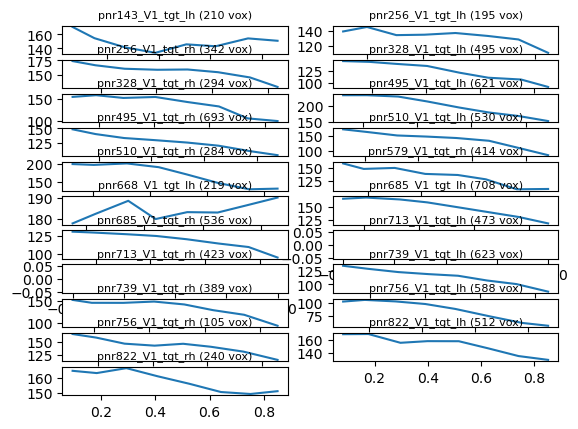

In [4]:
#%% Import Datasets and Check Stria of Gennari

mainDir = '.'
datasets = glob.glob(os.path.join(mainDir, 'roi_data_manualSeg/target_roi_manual', 'pnr???_??_???_??.csv'))
#datasets = glob.glob(os.path.join(mainDir, 'roi_data_manualSeg/target_filled', 'pnr???_??_???_??.csv'))
#or exclude
exclude_initial = ['pnr143_V1_tgt_rh','pnr161_V1_tgt_lh','pnr161_V1_tgt_rh','pnr352_V1_tgt_lh','pnr352_V1_tgt_rh','pnr579_V1_tgt_lh','pnr668_V1_tgt_rh']
#exclude_initial = ['pnr352_V1_tgt_lh_rad10']
for e_i, excl in enumerate(exclude_initial):
    datasets.remove(os.path.join(mainDir,'roi_data_manualSeg/target_roi_manual',excl+'.csv'))
    #datasets.remove(os.path.join(mainDir,'roi_data_manualSeg/target_filled',excl+'.csv'))        
datasets.sort()

# Set ROI radius: This is the radius (in sigma) that marks the boundary between
#     target- and surround-selective regions.
roiRad = 2 #1.

# Organize data into dictionary
import pandas as pd
all_data = {}
for dataset in datasets:
    p, f = os.path.split(dataset)
    f, ex = os.path.splitext(f)
    all_data[f] = pd.read_csv(dataset, sep=',', index_col=False)
    
## Remove d = 0 voxels: Some voxels do not receive a depth label. We only 
#       analyze voxels with valid depth labels.
for iR, label in enumerate(all_data.keys()):
    df = all_data[label]
    
    df = df.drop(df[df['d'] == 0].index)
    
    all_data[label] = df

# Check what the Stria profile looks like in each ROI
nDepths = 7
fig = plt.figure(num=1)
fig.clf()
for iR, label in enumerate(all_data.keys()):
    df = all_data[label]
    
    roi = df[df['scale_xy_dist'] < roiRad]
    roi = roi[roi['scale_xy_dist'] > 0]
    dataDict = makeProfile1D(roi['d'].values,
                             8, #number of depths
                             roi['t1'].values,
                             np.min(roi['d'].values), #min depth value
                             np.max(roi['d'].values), #max depth value
                             True) #Use LayNii values
    
    plt.subplot(int(np.ceil(len(all_data.keys())/2.)), 2, 1 + iR)
    plt.plot(dataDict['profile']['depth'],
             dataDict['profile']['avg'][0])
    plt.title('%s (%d vox)' %(label, len(roi)), fontsize=8)
    
if savefigs:
    fig.savefig(os.path.join(figDir,'t1w_profiles.%s' %(fig_format)))

avg radius: 2.49
avg radius: 3.10
avg radius: 3.49
avg radius: 4.42
avg radius: 3.32
avg radius: 4.79


/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('p

avg radius: 4.93
avg radius: 4.46
avg radius: 3.16
avg radius: 3.74
avg radius: 2.97
avg radius: 5.03
avg radius: 4.05


/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('p

avg radius: 4.32
avg radius: 3.48
avg radius: 5.30
avg radius: 4.14


/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('p

avg radius: 5.05
avg radius: 1.94
avg radius: 4.60
avg radius: 3.68


/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1105386056.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = plt.cm.get_cmap('p

<Figure size 800x800 with 0 Axes>

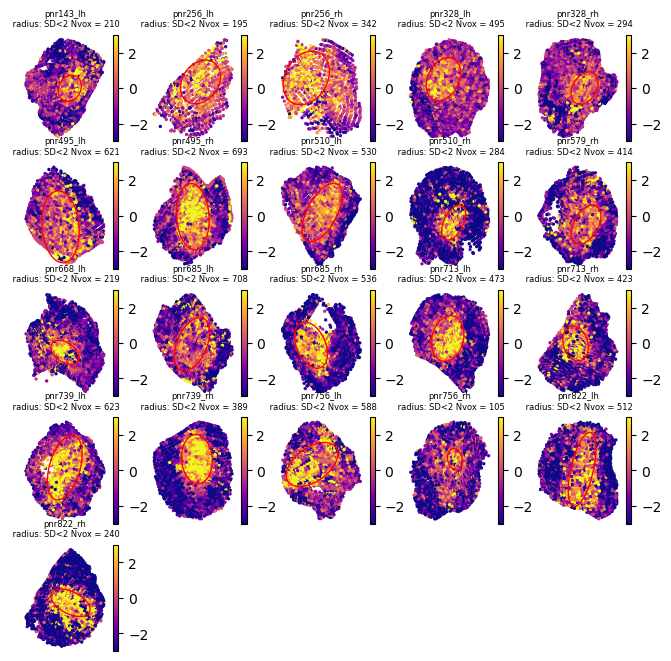

In [5]:
#%% Check on xy to uv mapping
from matplotlib.patches import Ellipse

show_rad = False
frad = plt.figure(figsize=(8,8))
floc = plt.figure(figsize=(8,8))
for iR, label in enumerate(all_data.keys()):
    df = all_data[label]
    subjID = label[0:6]
    hemi = label[14:16]

    # redo the ellipse fitting, which is a bit of overkill, but it gets us 
    # an accurate ellipse
    tgt_df = df[df['ctr-sur'] > 0]
    #tgt_df = df[df['scale_xy_dist'] <= 2]
    cov = np.cov(tgt_df['x'][df['scale_xy_dist'] < 2.2],
                 tgt_df['y'][df['scale_xy_dist'] < 2.2])
    com = (np.mean(tgt_df['x'][df['scale_xy_dist'] < 2.2]),
           np.mean(tgt_df['y'][df['scale_xy_dist'] < 2.2]))
    a = (cov[0,0] + cov[1,1])/2 + np.sqrt(((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
    b = (cov[0,0] + cov[1,1])/2 - np.sqrt(((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
    print('avg radius: %2.2f' %(2*(np.sqrt(a) + np.sqrt(b))/2))
    theta = np.arctan2(a - cov[0,0], cov[1,0])
    ellipse = Ellipse(com,
                      width=2*2*np.sqrt(a),
                      height=2*2*np.sqrt(b),
                      angle=180*theta/np.pi,
                      zorder=100, alpha=1., edgecolor='r', facecolor='None')
    
    if show_rad:
        # show localizer data
        minx = np.min(df['x'].values)
        miny = np.min(df['y'].values)
        ax = frad.add_subplot(int(np.ceil(np.sqrt(len(datasets)))),int(np.ceil(np.sqrt(len(datasets)))),iR+1)
        
        # Plot the radius determined by the normalized uv coordinates (this should be in SD of a 2D Gaussian fitted to the loc data)
        cmap = plt.cm.get_cmap('viridis')
        pcm = ax.scatter(df['x'],df['y'],c=df['scale_xy_dist'],s=2,cmap=cmap)
        cbar = plt.colorbar(pcm,ax=ax)
        ax.add_patch(ellipse)
        ax.patch.set_facecolor('r')
        ax.set_title(label+" radius: SD<2 Nvox = %d" %(np.sum(df['scale_xy_dist']<2)),fontsize=6)
        ax.axis('off')
    
    else:
        # Plot the ctr-sur betas
        ax2 = floc.add_subplot(int(np.ceil(np.sqrt(len(datasets)))),int(np.ceil(np.sqrt(len(datasets)))),iR+1)
        cmap2 = plt.cm.get_cmap('plasma')
        pcm = ax2.scatter(df['x'],df['y'],c=df['ctr-sur_unwarp'],s=2,cmap=cmap2,vmin=-3,vmax=3)
        cbar2 = plt.colorbar(pcm,ax=ax2)
        ax2.add_patch(ellipse)
        ax2.patch.set_facecolor('r')
        ax2.set_title(subjID+"_"+hemi+"\n radius: SD<2 Nvox = %d" %(np.sum(df['scale_xy_dist']<2)),fontsize=6)
        ax2.axis('off')
    
if savefigs:
    frad.savefig(os.path.join(figDir,'xy_map_rad.%s' %(fig_format)))
    floc.savefig(os.path.join(figDir,'xy_map_loc.%s' %(fig_format)))

/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/3145451175.py:17: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  floc.tight_layout(pad=0.1)
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/3145451175.py:33: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  ftask.tight_layout(pad=0.1)


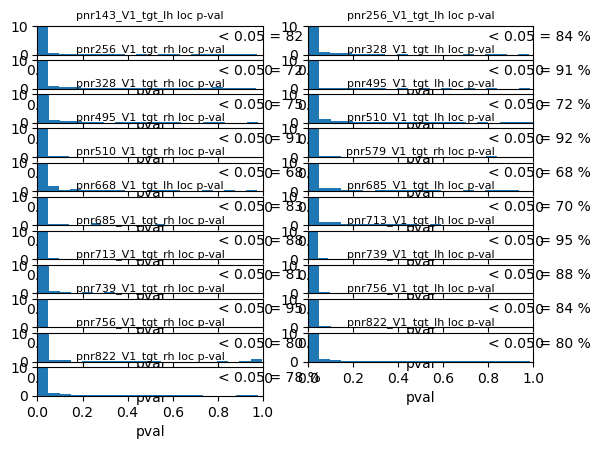

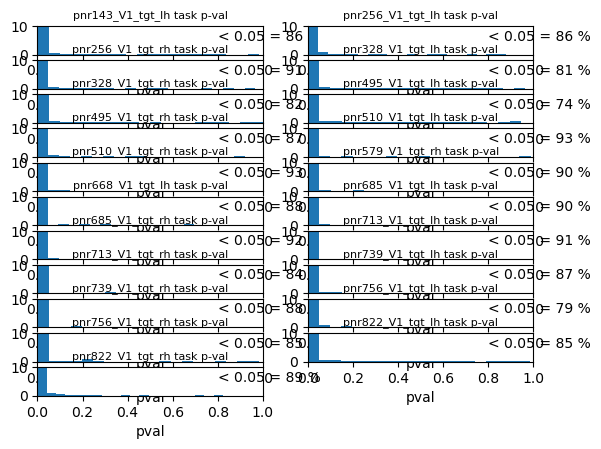

In [6]:
#%% Histograms of p-values
#       Check that enough voxels are responsive to the stimulus
floc = plt.figure()
for iR, label in enumerate(all_data.keys()):
    df = all_data[label]
    
    roi = df[df['scale_xy_dist'] < roiRad]
    if 'loc pval' in roi.keys():
        roi = roi.rename(columns={'loc pval':'loc p-val'})
    plt.subplot(int(np.ceil(len(datasets)/2)),2,iR+1)
    plt.hist(roi['loc p-val'].values,bins=20,density=True)
    plt.title(label+" loc p-val",fontsize=8)
    plt.xlabel("pval")
    plt.text(0.8,5,'< 0.05 = %d %%' %(100*np.sum(roi['loc p-val'] <= 0.05)/len(roi['loc p-val'])))
    plt.ylim([0,10])
    plt.xlim([0,1])
floc.tight_layout(pad=0.1)

ftask = plt.figure()
for iR, label in enumerate(all_data.keys()):
    df = all_data[label]
    
    roi = df[df['scale_xy_dist'] < roiRad]
    if 'task pval' in roi.keys():
        roi = roi.rename(columns={'task pval':'task p-val'})
    plt.subplot(int(np.ceil(len(datasets)/2)),2,iR+1)
    plt.hist(roi['task p-val'].values,bins=20,density=True)
    plt.title(label+" task p-val",fontsize=8)
    plt.xlabel("pval")
    plt.text(0.8,5,'< 0.05 = %d %%' %(100*np.sum(roi['task p-val'] <= 0.05)/len(roi['task p-val'])))
    plt.ylim([0,10])
    plt.xlim([0,1])
ftask.tight_layout(pad=0.1)

if savefigs:
    floc.savefig(os.path.join(figDir,'pvals_loc.%s' %(fig_format)))
    ftask.savefig(os.path.join(figDir,'pvals_task.%s' %(fig_format)))

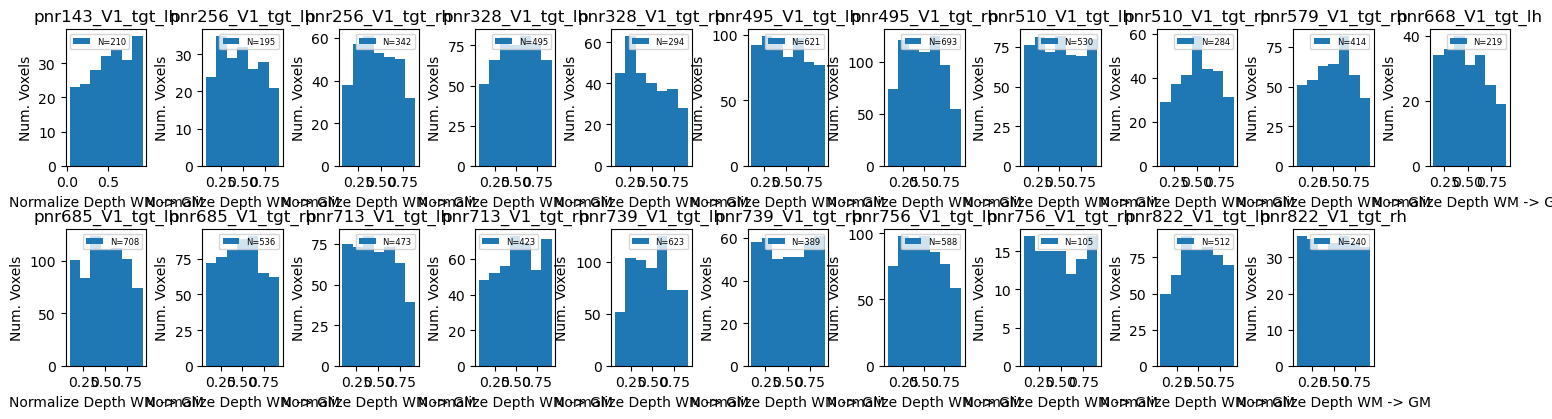

In [6]:
#%% Depth Histograms
#       Check coverage across depth for each ROI
fdhist = plt.figure(figsize=(15,4))

for iR, label in enumerate(all_data.keys()):
    df = all_data[label]
    
    roi = df[df['scale_xy_dist'] < roiRad]
    roi = df[df['scale_xy_dist'] < roiRad]
    if 'loc pval' in roi.keys():
        roi = roi.rename(columns={'loc pval':'loc p-val'})
    plt.subplot(2,int(np.ceil(len(datasets)/2)),iR+1)
    plt.hist(roi['d'].values,bins=nDepths)
    plt.title(label)
    plt.xlabel("Normalize Depth WM -> GM")
    plt.ylabel("Num. Voxels")
    plt.legend(['N='+str(len(roi)),], fontsize = 6)
fdhist.tight_layout(pad=0.0)

if savefigs:
    fdhist.savefig(os.path.join(figDir,'depth_hist.%s' %(fig_format)))

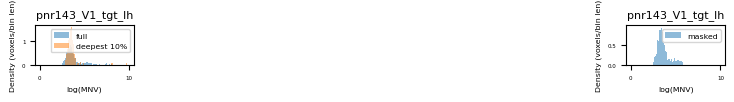

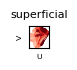

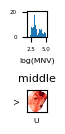

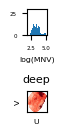

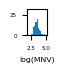

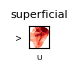

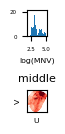

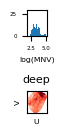

2314/2501 Voxels Survive for pnr143_V1_tgt_lh
	 805/937 Voxels Survive for superficial pnr143_V1_tgt_lh
	 637/663 Voxels Survive for middle pnr143_V1_tgt_lh
	 872/901 Voxels Survive for deep pnr143_V1_tgt_lh


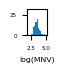

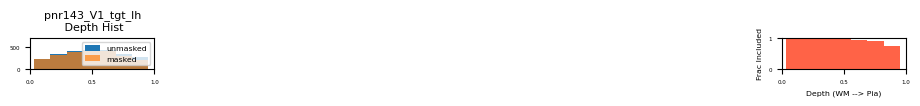

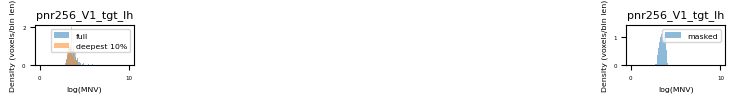

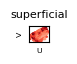

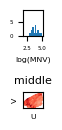

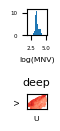

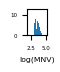

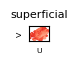

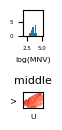

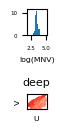

662/787 Voxels Survive for pnr256_V1_tgt_lh
	 215/305 Voxels Survive for superficial pnr256_V1_tgt_lh
	 168/193 Voxels Survive for middle pnr256_V1_tgt_lh
	 279/289 Voxels Survive for deep pnr256_V1_tgt_lh


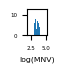

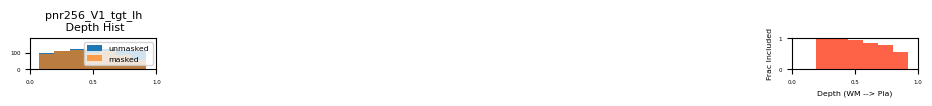

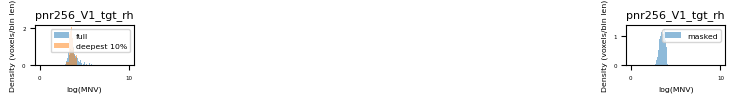

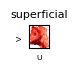

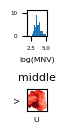

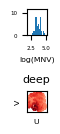

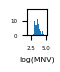

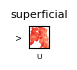

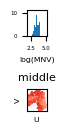

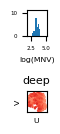

805/1046 Voxels Survive for pnr256_V1_tgt_rh
	 250/367 Voxels Survive for superficial pnr256_V1_tgt_rh
	 221/302 Voxels Survive for middle pnr256_V1_tgt_rh
	 334/377 Voxels Survive for deep pnr256_V1_tgt_rh


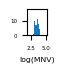

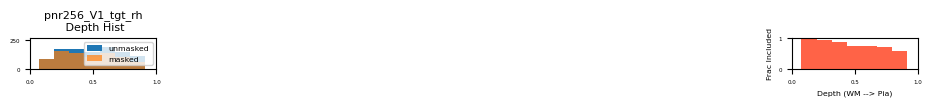

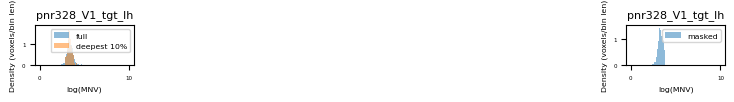

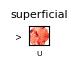

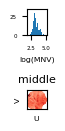

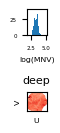

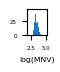

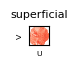

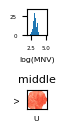

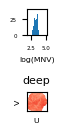

3022/3438 Voxels Survive for pnr328_V1_tgt_lh
	 1032/1305 Voxels Survive for superficial pnr328_V1_tgt_lh
	 766/858 Voxels Survive for middle pnr328_V1_tgt_lh
	 1224/1275 Voxels Survive for deep pnr328_V1_tgt_lh


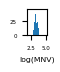

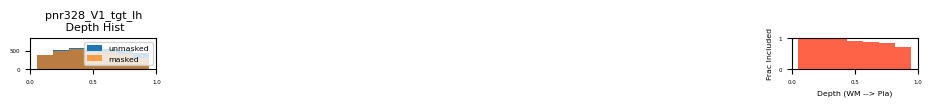

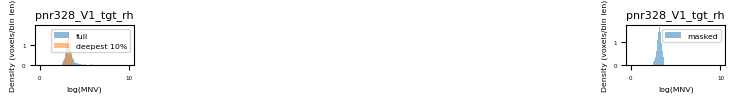

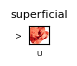

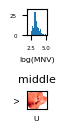

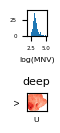

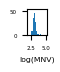

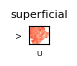

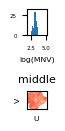

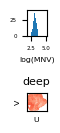

2572/3040 Voxels Survive for pnr328_V1_tgt_rh
	 771/1076 Voxels Survive for superficial pnr328_V1_tgt_rh
	 712/817 Voxels Survive for middle pnr328_V1_tgt_rh
	 1089/1147 Voxels Survive for deep pnr328_V1_tgt_rh


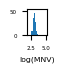

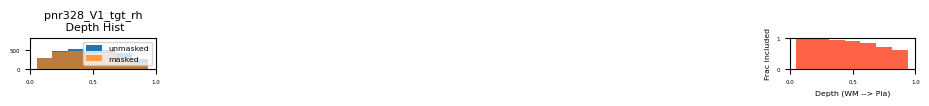

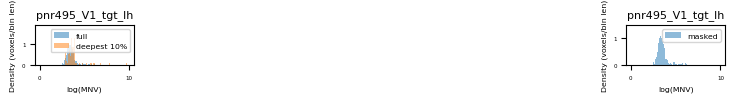

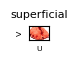

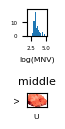

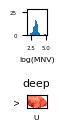

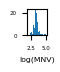

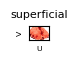

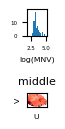

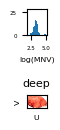

1805/1862 Voxels Survive for pnr495_V1_tgt_lh
	 660/687 Voxels Survive for superficial pnr495_V1_tgt_lh
	 437/446 Voxels Survive for middle pnr495_V1_tgt_lh
	 708/729 Voxels Survive for deep pnr495_V1_tgt_lh


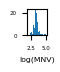

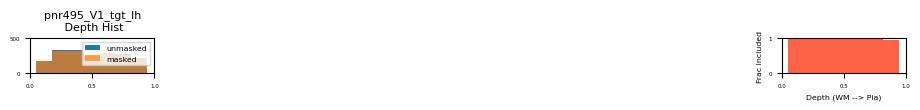

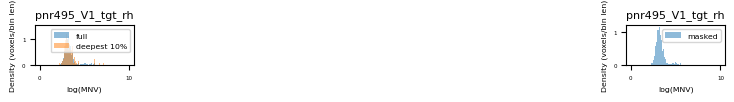

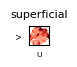

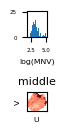

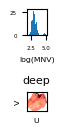

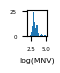

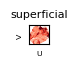

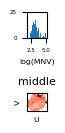

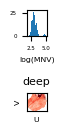

2200/2317 Voxels Survive for pnr495_V1_tgt_rh
	 829/880 Voxels Survive for superficial pnr495_V1_tgt_rh
	 571/600 Voxels Survive for middle pnr495_V1_tgt_rh
	 800/837 Voxels Survive for deep pnr495_V1_tgt_rh


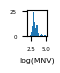

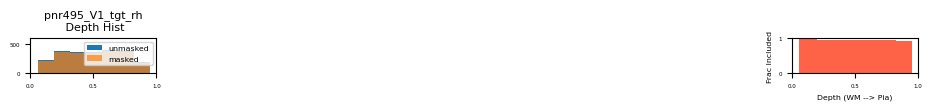

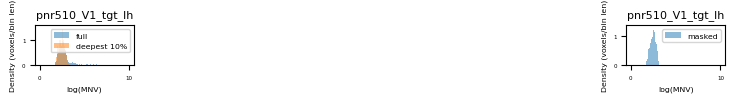

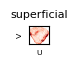

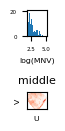

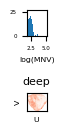

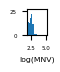

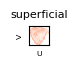

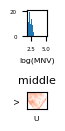

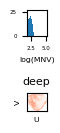

1733/2095 Voxels Survive for pnr510_V1_tgt_lh
	 497/813 Voxels Survive for superficial pnr510_V1_tgt_lh
	 529/557 Voxels Survive for middle pnr510_V1_tgt_lh
	 707/725 Voxels Survive for deep pnr510_V1_tgt_lh


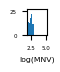

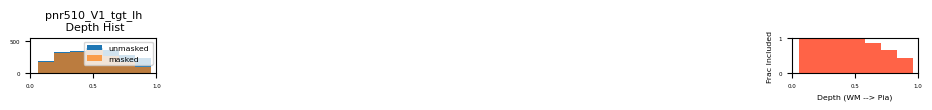

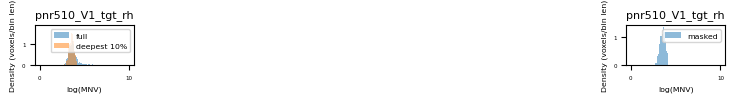

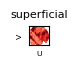

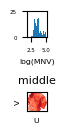

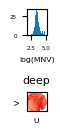

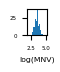

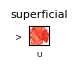

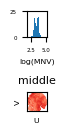

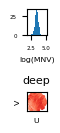

2445/2895 Voxels Survive for pnr510_V1_tgt_rh
	 749/1075 Voxels Survive for superficial pnr510_V1_tgt_rh
	 682/770 Voxels Survive for middle pnr510_V1_tgt_rh
	 1014/1050 Voxels Survive for deep pnr510_V1_tgt_rh


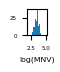

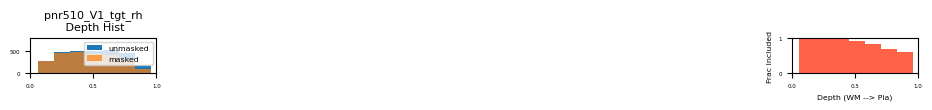

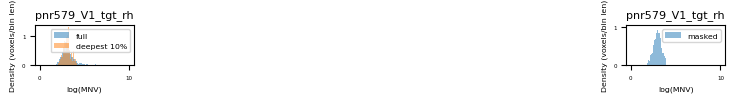

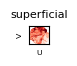

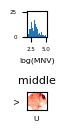

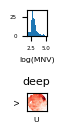

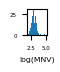

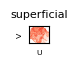

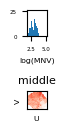

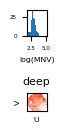

2399/2776 Voxels Survive for pnr579_V1_tgt_rh
	 742/1053 Voxels Survive for superficial pnr579_V1_tgt_rh
	 718/757 Voxels Survive for middle pnr579_V1_tgt_rh
	 939/966 Voxels Survive for deep pnr579_V1_tgt_rh


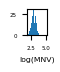

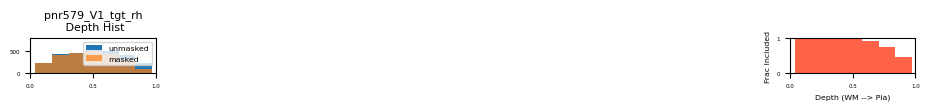

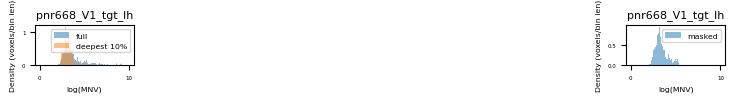

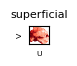

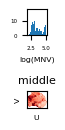

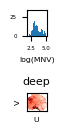

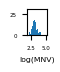

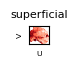

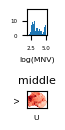

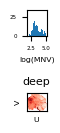

2275/2523 Voxels Survive for pnr668_V1_tgt_lh
	 722/886 Voxels Survive for superficial pnr668_V1_tgt_lh
	 744/806 Voxels Survive for middle pnr668_V1_tgt_lh
	 809/831 Voxels Survive for deep pnr668_V1_tgt_lh


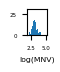

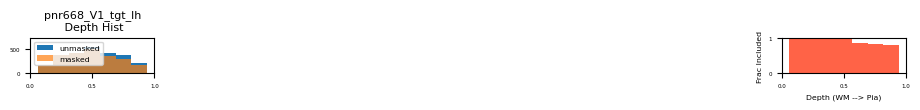

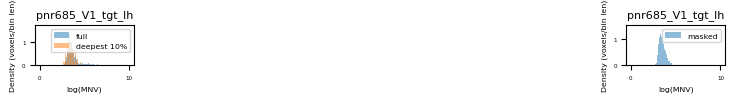

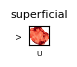

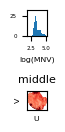

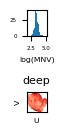

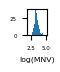

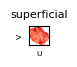

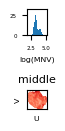

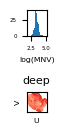

2664/2951 Voxels Survive for pnr685_V1_tgt_lh
	 870/1079 Voxels Survive for superficial pnr685_V1_tgt_lh
	 773/828 Voxels Survive for middle pnr685_V1_tgt_lh
	 1021/1044 Voxels Survive for deep pnr685_V1_tgt_lh


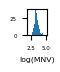

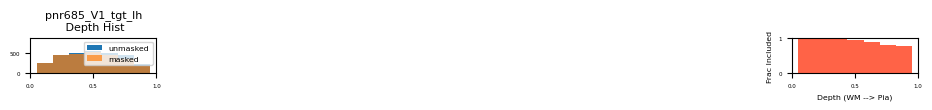

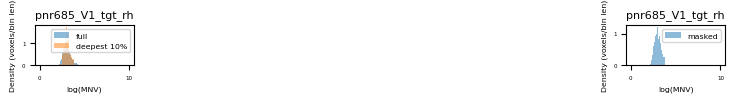

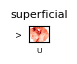

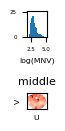

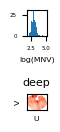

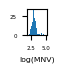

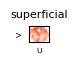

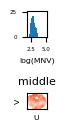

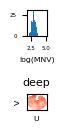

2327/2503 Voxels Survive for pnr685_V1_tgt_rh
	 823/930 Voxels Survive for superficial pnr685_V1_tgt_rh
	 664/687 Voxels Survive for middle pnr685_V1_tgt_rh
	 840/886 Voxels Survive for deep pnr685_V1_tgt_rh


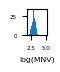

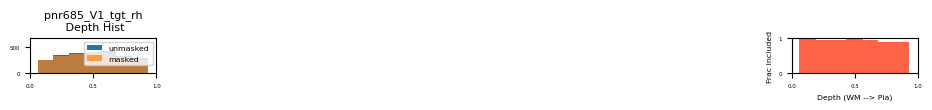

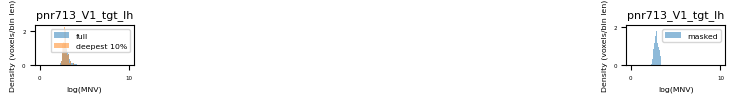

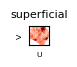

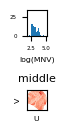

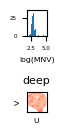

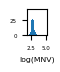

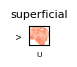

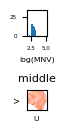

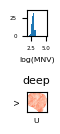

2065/2471 Voxels Survive for pnr713_V1_tgt_lh
	 602/924 Voxels Survive for superficial pnr713_V1_tgt_lh
	 569/619 Voxels Survive for middle pnr713_V1_tgt_lh
	 894/928 Voxels Survive for deep pnr713_V1_tgt_lh


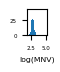

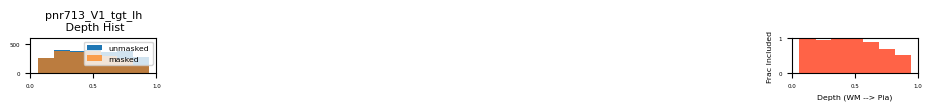

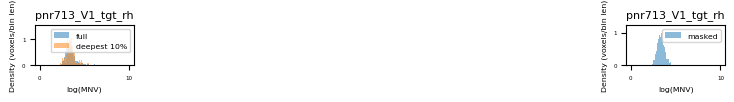

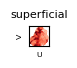

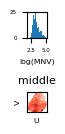

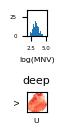

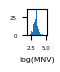

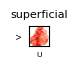

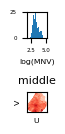

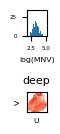

2502/2713 Voxels Survive for pnr713_V1_tgt_rh
	 907/1093 Voxels Survive for superficial pnr713_V1_tgt_rh
	 701/701 Voxels Survive for middle pnr713_V1_tgt_rh
	 894/919 Voxels Survive for deep pnr713_V1_tgt_rh


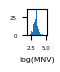

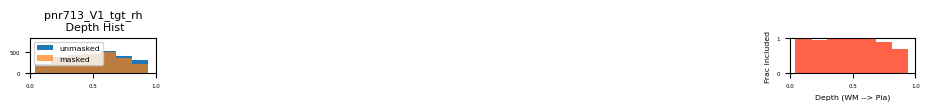

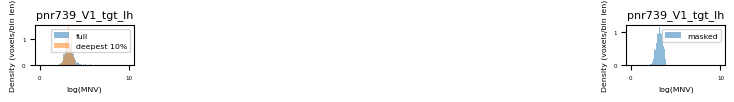

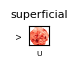

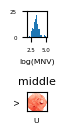

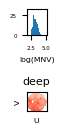

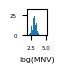

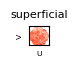

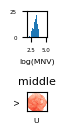

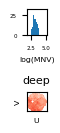

2132/2405 Voxels Survive for pnr739_V1_tgt_lh
	 640/856 Voxels Survive for superficial pnr739_V1_tgt_lh
	 667/717 Voxels Survive for middle pnr739_V1_tgt_lh
	 825/832 Voxels Survive for deep pnr739_V1_tgt_lh


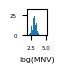

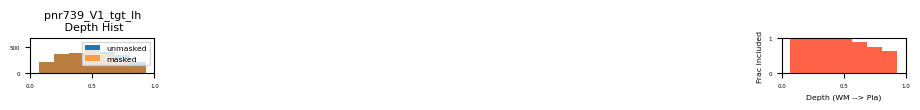

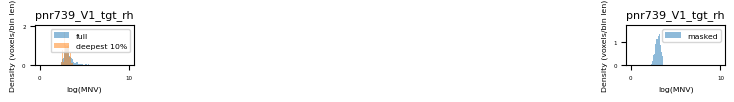

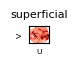

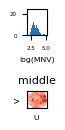

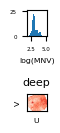

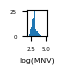

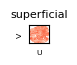

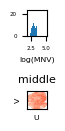

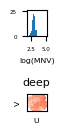

1748/2248 Voxels Survive for pnr739_V1_tgt_rh
	 503/872 Voxels Survive for superficial pnr739_V1_tgt_rh
	 434/520 Voxels Survive for middle pnr739_V1_tgt_rh
	 811/856 Voxels Survive for deep pnr739_V1_tgt_rh


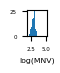

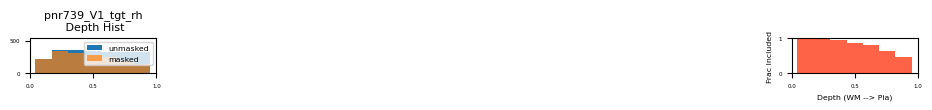

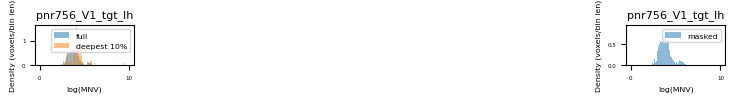

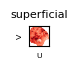

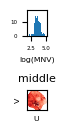

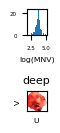

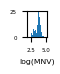

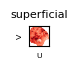

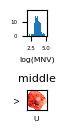

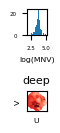

2069/2106 Voxels Survive for pnr756_V1_tgt_lh
	 807/823 Voxels Survive for superficial pnr756_V1_tgt_lh
	 512/513 Voxels Survive for middle pnr756_V1_tgt_lh
	 750/770 Voxels Survive for deep pnr756_V1_tgt_lh


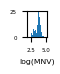

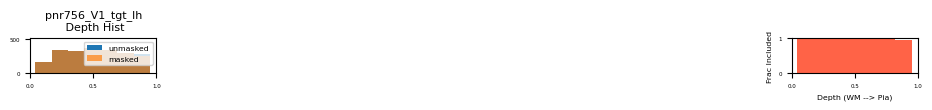

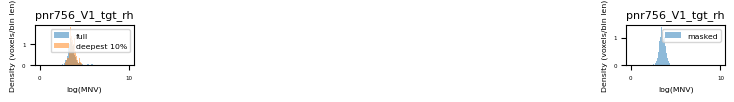

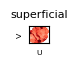

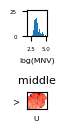

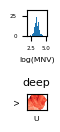

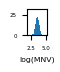

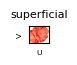

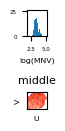

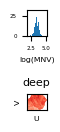

2076/2262 Voxels Survive for pnr756_V1_tgt_rh
	 724/863 Voxels Survive for superficial pnr756_V1_tgt_rh
	 545/563 Voxels Survive for middle pnr756_V1_tgt_rh
	 807/836 Voxels Survive for deep pnr756_V1_tgt_rh


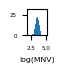

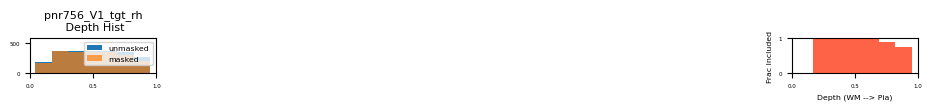

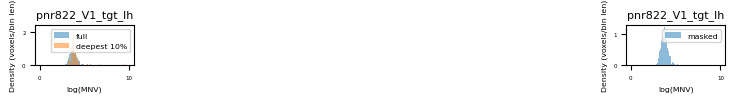

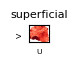

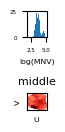

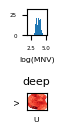

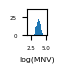

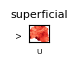

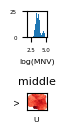

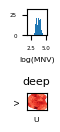

2373/2485 Voxels Survive for pnr822_V1_tgt_lh
	 818/895 Voxels Survive for superficial pnr822_V1_tgt_lh
	 675/696 Voxels Survive for middle pnr822_V1_tgt_lh
	 880/894 Voxels Survive for deep pnr822_V1_tgt_lh


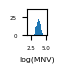

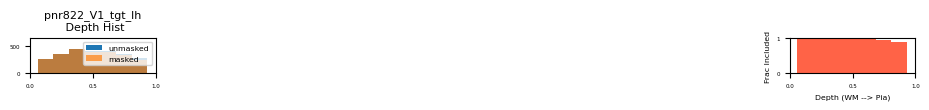

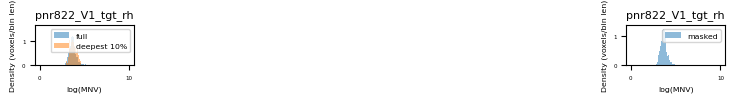

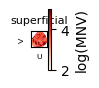

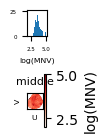

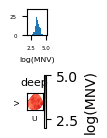

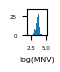

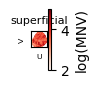

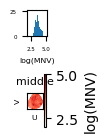

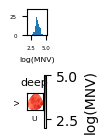

2157/2253 Voxels Survive for pnr822_V1_tgt_rh
	 766/852 Voxels Survive for superficial pnr822_V1_tgt_rh
	 590/594 Voxels Survive for middle pnr822_V1_tgt_rh
	 801/807 Voxels Survive for deep pnr822_V1_tgt_rh


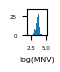

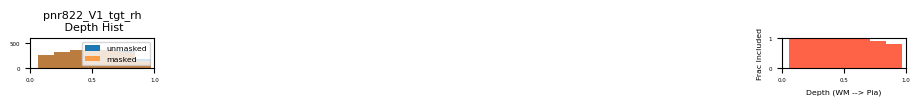

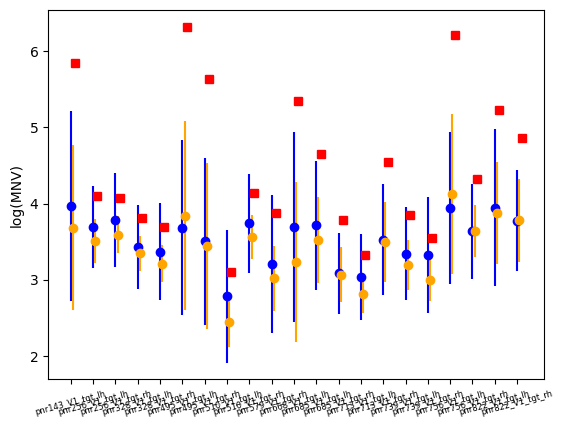

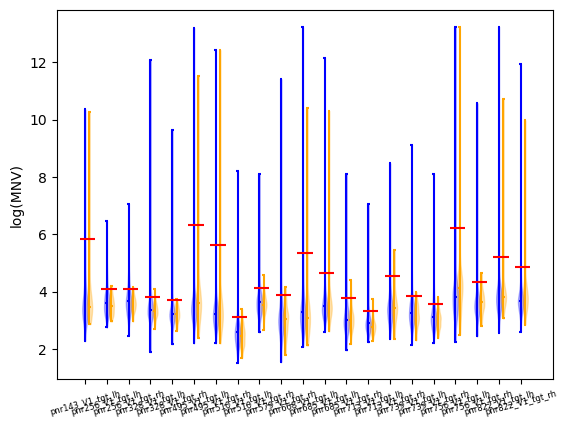

In [7]:
#%% Devein
#       Use the deepest layer as a proxy for non-vein contaminated voxels
#       Then define the threshold based on this distribution

deep_pct = 10 #percentile to call deep layers
conditions = ['iso0','iso90','orth','sur']
depth_groups = {'deep': [0.2,0.4], 'middle': [0.4,0.6], 'superficial': [0.6,0.8]}
depth_labels = ['superficial','middle','deep'] #put them in the right order
depth_var = 'd'
x_var = 'x'
y_var = 'y'
sd_thresh = 2 #how many st. dev. of the deep layer mean to use as the threshold
mask_dict = {} #create a mask dictionary
lmnv_dict = {key:{'mean':0,'std':0,'thresh':0,'deep_mean':0,'deep_std':0} for key in all_data.keys()} #thresh dictionary
fsize=8 #fontsize of title
depth_groups = {'deep': [0.2,0.4], 'middle': [0.4,0.6], 'superficial': [0.6,0.8]}
depth_labels = ['superficial','middle','deep'] #put them in the right order
Ngroups = len(depth_groups.keys())
NROIs = len(all_data.keys())
for k_i, key in enumerate(all_data.keys()):

    # calculate log(MNV)
    df = all_data[key]
    lmnv = get_lmnv(df,key='stdev_xerrts') #log of the mean-normalized variance
    mnv = np.exp(lmnv) #get back mean normalized variance
    
    # get deep layer distribution
    z = df[depth_var]
    [deep_mean, deep_std, deep] = get_deep_layer_dist(df,depth_var,deep_pct)
    lmnv_dict[key]['deep_mean'] = deep_mean
    lmnv_dict[key]['deep_std'] = deep_std
    
    # define threshold based on deep layer distribution
    [mnv_mask, lmnv_thresh] = get_mnv_mask(df,depth_var,deep_pct,sd_thresh)
    lmnv_dict[key]['thresh'] = lmnv_thresh
    lmnv_dict[key]['mean'] = np.mean(lmnv)
    lmnv_dict[key]['std'] = np.std(lmnv)
    mask_dict[key] = mnv_mask
    all_data[key]['no_vein'] = mnv_mask
    
    # Plot distributions
    fthresh = plot_mnv_histograms(lmnv, lmnv[deep], mnv_mask, deep_pct, key, k_i, NROIs, fsize, pad=0.0, figsize=(15,3))
    
    # Plot depth maps
    dmap = plot_depth_maps(df, depth_var, depth_groups, depth_labels, x_var, y_var, mnv, k_i, NROIs, [2,5], fsize, fname = 'dmap', pad=0.0)
        
    #plot thresholded map
    dmap_thresh = plot_depth_maps(df, depth_var, depth_groups, depth_labels, x_var, y_var, mnv, k_i, NROIs, [2,5], fsize, fname='dmap_thresh', mask=mnv_mask, pad=0.0)
        
    # Plot voxel loss at each depth after masking
    fdepth_hist = plot_depth_voxel_loss(z, mnv_mask, nDepths, NROIs, key, k_i, fsize)
    
    #report number of voxels after threshold
    print("%d/%d Voxels Survive for %s" %(np.sum(mnv_mask),np.size(mnv),key))
    superficial_mask = (z>=depth_groups['superficial'][0])
    middle_mask = (z>=depth_groups['middle'][0])*(z<depth_groups['middle'][1])
    deep_mask = (z<depth_groups['deep'][1])
    print("\t %d/%d Voxels Survive for superficial %s" %(np.sum(mnv_mask*superficial_mask),np.sum(superficial_mask),key))
    print("\t %d/%d Voxels Survive for middle %s" %(np.sum(mnv_mask*middle_mask),np.sum(middle_mask),key))
    print("\t %d/%d Voxels Survive for deep %s" %(np.sum(mnv_mask*deep_mask),np.sum(deep_mask),key))
    
if savefigs:
    fthresh.savefig(os.path.join(figDir,'mnv_hist.%s' %(fig_format)))
    dmap.savefig(os.path.join(figDir,'mnv_depth_map.%s' %(fig_format)))
    dmap_thresh.savefig(os.path.join(figDir,'mnv_depth_map_thresh.%s' %(fig_format)))
    fdepth_hist.savefig(os.path.join(figDir,'mnv_depth_hist.%s' %(fig_format)))

#%% Compare devein thresholds between subjects

f = plt.figure()
for k_i, key in enumerate(all_data.keys()):
    plt.errorbar(k_i,lmnv_dict[key]['mean'],lmnv_dict[key]['std'],color='b',linestyle='None',marker='o')
    plt.errorbar(k_i+0.1,lmnv_dict[key]['deep_mean'],lmnv_dict[key]['deep_std'],color='orange',linestyle='None',marker='o')
    plt.plot(k_i+0.2,lmnv_dict[key]['thresh'],color='r',marker='s')
plt.xticks(np.arange(0,len(all_data.keys())),all_data.keys(),rotation=15,fontsize=6)
plt.ylabel("log(MNV)")
#plt.legend(['full','thresh'])

if savefigs:
    f.savefig(os.path.join(figDir,'mnv_summary_errorbars.%s' %(fig_format)))

#try violin plots
spreadF = 2
f = plt.figure()
for k_i, key in enumerate(all_data.keys()):
    df = all_data[key]
    lmnv = get_lmnv(df,key='stdev_xerrts') #log of the mean-normalized variance
    notInf = (lmnv != np.inf) & (lmnv != -np.inf)
    lmnv = lmnv[notInf] #sometimes there are infinities from division by zero. I'll ignore these.
    [deep_mean, deep_std, deep] = get_deep_layer_dist(df,depth_var,deep_pct)
    deep = deep[notInf]
    violin_parts = plt.violinplot(lmnv,positions=[spreadF*k_i],showmedians=True)
    for pc in violin_parts['bodies']:
        pc.set_facecolor('b')
        pc.set_edgecolor('b')
    for pc in violin_parts:
        if not isinstance(violin_parts[pc],list):
            violin_parts[pc].set_edgecolor('b')
    violin_parts = plt.violinplot(lmnv[deep],positions=[spreadF*(k_i+0.2)],showmedians=True)
    for pc in violin_parts['bodies']:
        pc.set_facecolor('orange')
        pc.set_edgecolor('orange')
    for pc in violin_parts:
        if not isinstance(violin_parts[pc],list):
            violin_parts[pc].set_edgecolor('orange')
    plt.hlines(lmnv_dict[key]['thresh'],spreadF*k_i-0.5,spreadF*(k_i+0.2)+0.5,color='r')
plt.xticks(np.arange(0,spreadF*len(all_data.keys()),spreadF),all_data.keys(),rotation=15,fontsize=6)
plt.ylabel("log(MNV)")

if savefigs:
    f.savefig(os.path.join(figDir,'mnv_summary_violin.%s' %(fig_format)))

In [9]:
#%% Apply full model p-val mask
#       Only analyze voxels with significant responses to the stimuli

use_fullmodel_mask = True
pthresh_fullmodel = 0.05
if use_fullmodel_mask:
    for k_i, key in enumerate(all_data.keys()):
        df = all_data[key]
        pvals = df['task p-val']
        pval_mask = pvals < pthresh_fullmodel
        print("%d/%d voxels survive full model p-val mask" %(np.sum(pval_mask),np.size(pval_mask)))
        mask_dict[key] = mask_dict[key] & pval_mask   
        all_data[key]['sig'] = pval_mask
        
#pick out ROIs where we're sure of localization
roi_dict = {}
for key in all_data.keys():
    df = all_data[key]
    roi_dict[key] = df['scale_xy_dist'] < roiRad
    all_data[key]['in_tgt'] = df['scale_xy_dist'] < roiRad
    

2161/2501 voxels survive full model p-val mask
712/787 voxels survive full model p-val mask
958/1046 voxels survive full model p-val mask
2617/3438 voxels survive full model p-val mask
2290/3040 voxels survive full model p-val mask
1437/1862 voxels survive full model p-val mask
1964/2317 voxels survive full model p-val mask
1929/2095 voxels survive full model p-val mask
2676/2895 voxels survive full model p-val mask
2484/2776 voxels survive full model p-val mask
2182/2523 voxels survive full model p-val mask
2551/2951 voxels survive full model p-val mask
2178/2503 voxels survive full model p-val mask
2211/2471 voxels survive full model p-val mask
2219/2713 voxels survive full model p-val mask
2086/2405 voxels survive full model p-val mask
1957/2248 voxels survive full model p-val mask
1707/2106 voxels survive full model p-val mask
1834/2262 voxels survive full model p-val mask
2098/2485 voxels survive full model p-val mask
1931/2253 voxels survive full model p-val mask


In [10]:
#%% Compute average depth profiles

#information about what conditions to look at
statDetails = {'labels': ['sur', 'iso0', 'iso90', 'orth', 'ctr_unwarp', 'sur_unwarp', 'ctr-sur_unwarp'],
                'colors': [[.7, .7, .7], 'red', 'darkviolet', 'orange', 'gold', 'purple', 'coral']}
diffDetails = {}
diffDetails['statIDs'] = {'odss': ['orth','iso90'],
                          'fgm': ['iso90','iso0'],
                          'dsi': ['orth','iso0'],
                          'iso-sur': ['iso0','sur'],
                          'ctr-sur': ['ctr_unwarp','sur_unwarp'],
                          'iso90-sur': ['iso90','sur'],
                          'orth-sur': ['orth','sur']}
diffDetails['colors'] = ['green','magenta','cyan','black','coral','darkmagenta','darkturquoise']

#store masks for each ROI
masks = {}
masks['tgt'] = {roi:all_data[roi]['in_tgt']*all_data[roi]['sig']*all_data[roi]['no_vein'] for roi in all_data.keys()}
profile_method = 'bin' # bin or smooth
useSI = False #if True, use suppression index as contrast (cond1 - cond2)/(cond1 + cond2)
prop_err = False # do error propagation?
use_decon = True

depthProfiles = {}
diffProfiles = {}
#calculate average profiles
depthProfiles['tgt'] = compute_all_depth_profiles(all_data,statDetails,profile_method,nDepths,masks['tgt'],depthParam='d',radialParam='scale_xy_dist',spec_Drange='MinMax')
diffProfiles['tgt'] = compute_diff_profiles(all_data,statDetails,diffDetails['statIDs'],profile_method,nDepths,useSI,masks['tgt'],depthParam='d',radialParam='scale_xy_dist',spec_Drange='MinMax')


depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.11
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.12
depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.13
depth bin size: 0.13
depth bin siz

In [11]:
#%% Depth Deconvolution

#reformat data to fit decon_rois specs
keep_rois = np.zeros((NROIs,len(statDetails['labels']),nDepths))
for iR, roiID in enumerate(all_data.keys()):
    for iStat, stat in enumerate(statDetails['labels']):
        keep_rois[iR,iStat,:] = depthProfiles['tgt'][stat]['avg'][iR]
        
keep_diffs = np.zeros((NROIs,len(diffDetails['statIDs'].keys()),nDepths))
for iR, roiID in enumerate(all_data.keys()):
    for iDiff, diff in enumerate(diffDetails['statIDs'].keys()):
        keep_diffs[iR,iDiff,:] = diffProfiles['tgt'][diff]['avg'][iR]

#define point spread function
p2t_model = 6.2 #peak to tail ratio from Markuerkiaga et al. (2021) estimated for TE = 33.3 ms    
Nbins_model = 10 #number of bins used in the model from Markuerkiaga et al. (2021)
Nbins = nDepths #number of bins to use in this analysis

normalize_psf = False #True if you want to normalize the psf by the deepest layer  

decon_rois = depth_deconv(keep_rois,p2t_model,Nbins_model,Nbins,normalize_psf)
decon_diffs = depth_deconv(keep_diffs,p2t_model,Nbins_model,Nbins,normalize_psf)

#now put back in dictionary
for iStat, stat in enumerate(statDetails['labels']):
    depthProfiles['tgt'][stat]['avg_decon'] = np.squeeze(np.array(decon_rois)[:,iStat,:])
    
for iDiff, diff in enumerate(diffDetails['statIDs'].keys()):
    diffProfiles['tgt'][diff]['avg_decon'] = np.squeeze(np.array(decon_diffs)[:,iDiff,:])


avg radius: 2.49
avg radius: 3.10
avg radius: 3.49
avg radius: 4.42
avg radius: 3.32
avg radius: 4.79
avg radius: 4.93


/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plas

avg radius: 4.46
avg radius: 3.16
avg radius: 3.74
avg radius: 2.97
avg radius: 5.03
avg radius: 4.05
avg radius: 4.32


/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plas

avg radius: 3.48
avg radius: 5.30
avg radius: 4.14
avg radius: 5.05
avg radius: 1.94


...

/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plas

avg radius: 5.30
avg radius: 4.14


/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')


avg radius: 5.05
avg radius: 1.94
avg radius: 4.60
avg radius: 3.68
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0


/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_32914/1249912072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plas

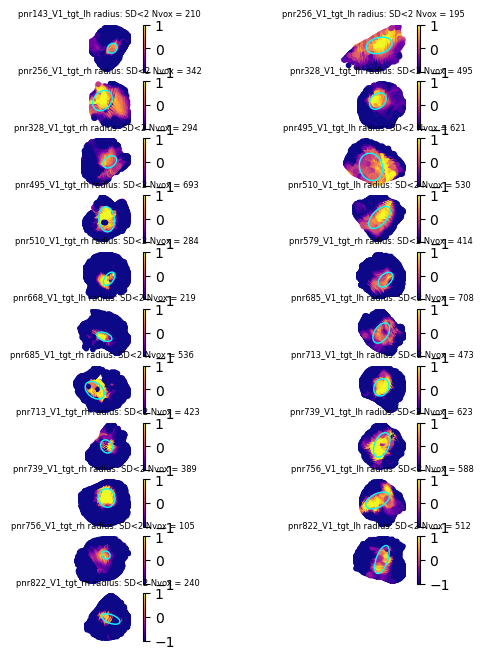

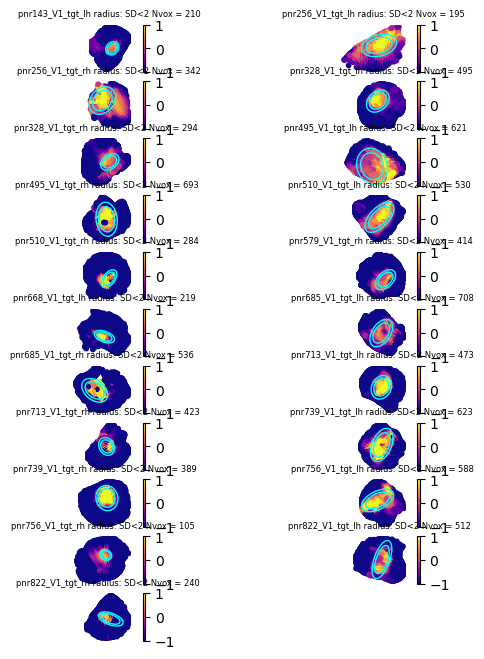

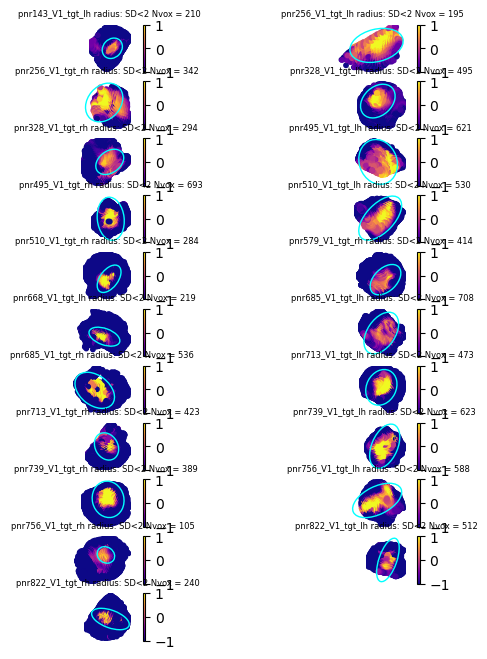

In [12]:
#%% Subregions

centerRad = 1.7 #center of ROI
borderRad = [1.7,2.3] #range for border
surRad = [3.5] #[3, 3.5] #outside of this range will be considered the surround
ring_rads = {'ctr':centerRad,'border':borderRad,'sur':surRad}
rings = ['ctr','border','sur']
nDepths_rings = 3 #number of depth bins to use for rings analysis

for r_i, ring in enumerate(rings):
    frad = plt.figure(figsize=(6.5,8))
    for iR, label in enumerate(all_data.keys()):
        df = all_data[label]
    
        # recapitulate the fitting, which is a bit of overkill, but it gets us 
        # an accurate ellipse
        tgt_df = df[df['ctr-sur'] > 0]
        #tgt_df = df[df['scale_xy_dist'] <= 2]
        cov = np.cov(tgt_df['x'][df['scale_xy_dist'] < 2.2],
                     tgt_df['y'][df['scale_xy_dist'] < 2.2])
        com = (np.mean(tgt_df['x'][df['scale_xy_dist'] < 2.2]),
               np.mean(tgt_df['y'][df['scale_xy_dist'] < 2.2]))
        a = (cov[0,0] + cov[1,1])/2 + np.sqrt(((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
        b = (cov[0,0] + cov[1,1])/2 - np.sqrt(((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
        print('avg radius: %2.2f' %(2*(np.sqrt(a) + np.sqrt(b))/2))
        theta = np.arctan2(a - cov[0,0], cov[1,0])
        
        # show localizer data
        minx = np.min(df['x'].values)
        miny = np.min(df['y'].values)
        ax = frad.add_subplot(int(np.ceil(len(datasets)/2)),2,iR+1)
        
        # Plot the radius determined by the normalized uv coordinates (this should be in SD of a 2D Gaussian fitted to the loc data)
        cmap = plt.cm.get_cmap('plasma')
        pcm = ax.scatter(df['x'],df['y'],c=df['ctr-sur'],s=10,cmap=cmap,vmin=-1,vmax=1)
        plt.colorbar(pcm,ax=ax)
        
        if ring == 'ctr':
            ellipse = Ellipse(com,
                          width=ring_rads[ring]*2*np.sqrt(a),
                          height=ring_rads[ring]*2*np.sqrt(b),
                          angle=180*theta/np.pi,
                          zorder=100, alpha=1, edgecolor='cyan', facecolor='None')
            ax.add_patch(ellipse)
        elif ring == 'sur':
            if len(ring_rads[ring]) == 1:
                ellipse = Ellipse(com,
                              width=ring_rads[ring][0]*2*np.sqrt(a),
                              height=ring_rads[ring][0]*2*np.sqrt(b),
                              angle=180*theta/np.pi,
                              zorder=100, alpha=1, edgecolor='cyan', facecolor='None')
                ax.add_patch(ellipse)
            elif len(ring_rads[ring]) > 1:
                ellipse1 = Ellipse(com,
                              width=ring_rads[ring][0]*2*np.sqrt(a),
                              height=ring_rads[ring][0]*2*np.sqrt(b),
                              angle=180*theta/np.pi,
                              zorder=100, alpha=1., edgecolor='cyan', facecolor='None')
                ellipse2 = Ellipse(com,
                              width=ring_rads[ring][1]*2*np.sqrt(a),
                              height=ring_rads[ring][1]*2*np.sqrt(b),
                              angle=180*theta/np.pi,
                              zorder=100, alpha=1., edgecolor='cyan', facecolor='None')
                ax.add_patch(ellipse1)
                ax.add_patch(ellipse2)
        elif ring == 'border':
            ellipse1 = Ellipse(com,
                          width=ring_rads[ring][0]*2*np.sqrt(a),
                          height=ring_rads[ring][0]*2*np.sqrt(b),
                          angle=180*theta/np.pi,
                          zorder=100, alpha=1., edgecolor='cyan', facecolor='None')
            ellipse2 = Ellipse(com,
                          width=ring_rads[ring][1]*2*np.sqrt(a),
                          height=ring_rads[ring][1]*2*np.sqrt(b),
                          angle=180*theta/np.pi,
                          zorder=100, alpha=1., edgecolor='cyan', facecolor='None')
            ax.add_patch(ellipse1)
            ax.add_patch(ellipse2)
        ax.patch.set_facecolor('r')
        ax.set_title(label+" radius: SD<2 Nvox = %d" %(np.sum(df['scale_xy_dist']<2)),fontsize=6)
        ax.set_aspect('equal')
        ax.axis('off')
        
    if savefigs:
        frad.savefig(os.path.join(figDir,'rings_graphics','rings_map_%s.%s' %(ring,fig_format)))

# Add columns to specify subregions
for k_i, key in enumerate(all_data.keys()):
    
    df = all_data[key]
    
    #subregion assignment
    df['in_ctr'] = df['scale_xy_dist'] <= centerRad
    df['in_border'] = (df['scale_xy_dist'] > borderRad[0]) & (df['scale_xy_dist'] <= borderRad[1])
    if len(surRad) > 1:
        df['in_sur'] = (df['scale_xy_dist'] > surRad[0]) & (df['scale_xy_dist'] <= surRad[1])
    else:
        df['in_sur'] = df['scale_xy_dist'] >= surRad[0]
    
    #depth reassignment
    d_bins_rings = bin_depths(df['d'].values,nDepths_rings,np.min(df['d'].values),np.max(df['d'].values),True)
    df['d_bin_rings'] = d_bins_rings
    
    all_data[key] = df

In [13]:
#%% Compare depth profiles at different radii

#pick out ROIs where we're sure of localization
masks['ctr'] = {}
masks['border'] = {}
masks['sur'] = {}
for key in all_data.keys():
    df = all_data[key]
    masks['ctr'][key] = df['in_ctr']*df['sig']*df['no_vein']
    masks['border'][key] = df['in_border']*df['sig']*df['no_vein']
    masks['sur'][key] = df['in_sur']*df['sig']*df['no_vein']
    
for r_i, ring in enumerate(rings):
    depthProfiles[ring] = compute_all_depth_profiles(all_data,statDetails,profile_method,nDepths_rings,masks[ring],depthParam='d',radialParam='scale_xy_dist',spec_Drange='MinMax')
    diffProfiles[ring] = compute_diff_profiles(all_data,statDetails,diffDetails['statIDs'],profile_method,nDepths_rings,useSI,masks[ring],depthParam='d',radialParam='scale_xy_dist',spec_Drange='MinMax')

 

depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.26
depth bin size: 0.26
depth bin size: 0.26
depth bin size: 0.26
depth bin size: 0.26
depth bin size: 0.26
depth bin size: 0.26
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.27
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.28
depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.30
depth bin size: 0.30
depth bin siz

In [14]:
#%% Deconvolution for subregions

#reformat data to fit decon_rois specs
keep_rois = {}
keep_diffs = {}
for r_i,ring in enumerate(rings):
    
    keep_rois[ring] = np.zeros((NROIs,len(statDetails['labels']),nDepths_rings))
    for iR, roiID in enumerate(all_data.keys()):
        for iStat, stat in enumerate(statDetails['labels']):
            keep_rois[ring][iR,iStat,:] = depthProfiles[ring][stat]['avg'][iR]
            
    keep_diffs[ring] = np.zeros((NROIs,len(diffDetails['statIDs'].keys()),nDepths_rings))
    for iR, roiID in enumerate(all_data.keys()):
        for iDiff, diff in enumerate(diffDetails['statIDs'].keys()):
            keep_diffs[ring][iR,iDiff,:] = diffProfiles[ring][diff]['avg'][iR]
    
    #define point spread function
    p2t_model = 6.2 #peak to tail ratio from Markuerkiaga et al. (2021) estimated for TE = 33.3 ms    
    Nbins_model = 10 #number of bins used in the model from Markuerkiaga et al. (2021)
    Nbins = nDepths_rings #number of bins to use in this analysis
    
    normalize_psf = False #True if you want to normalize the psf by the deepest layer  
    
    decon_rois = depth_deconv(keep_rois[ring],p2t_model,Nbins_model,Nbins,normalize_psf)
    decon_diffs = depth_deconv(keep_diffs[ring],p2t_model,Nbins_model,Nbins,normalize_psf)
    
    #now put back in dictionary
    for iStat, stat in enumerate(statDetails['labels']):
        depthProfiles[ring][stat]['avg_decon'] = np.squeeze(np.array(decon_rois)[:,iStat,:])
        
    for iDiff, diff in enumerate(diffDetails['statIDs'].keys()):
        diffProfiles[ring][diff]['avg_decon'] = np.squeeze(np.array(decon_diffs)[:,iDiff,:])
      

In [15]:
#%% Restructure datafile to fit formatting for mixedlm
# New data should be organized with each category lised as a column in a 
# dataframe. The categories are nested:
#     subject
    # |
    # `-- hemisphere
    #        |
    #         `-- depth bin
    #                 |
    #                 `-- condition
    
# First, concatenate all of the subjects and ROIs and add labels for each
for k_i, key in enumerate(all_data.keys()):
    
    df = all_data[key]
    
    #subject ID
    subjID = key[key.find('pnr'):key.find('pnr')+6]
    
    #hemisphere
    if 'rh' in key:
        hemi = 'rh'
    elif 'lh' in key:
        hemi = 'lh'
    else:
        hemi = None
        print('No hemisphere label!!!')
        
    #depth bin
    d_bins = bin_depths(df['d'].values,nDepths,np.min(df['d'].values),np.max(df['d'].values),True)
    
    #contrasts
    for c_i, contrast in enumerate(diffDetails['statIDs'].keys()):
        df[contrast] = df[diffDetails['statIDs'][contrast][0]]-df[diffDetails['statIDs'][contrast][1]]
      
    #add new columns
    df['subjID'] = subjID
    df['hemi'] = hemi
    df['d_bin'] = d_bins
    
    # Now, to do statistics on the deconvolved profiles, recenter the voxel
    #   distributions in each depth bin on the deconvolved average. First calculate
    #   the difference in average activation before and after deconvolution, then
    #   apply difference to each voxel.

    # for target ROI
    for iStat, stat in enumerate(statDetails['labels']):
        depthProfiles['tgt'][stat]['decon_diff'] = depthProfiles['tgt'][stat]['avg'] - depthProfiles['tgt'][stat]['avg_decon']
        df[stat+'_decon'] = np.zeros(len(df))
        for d_i in range(nDepths):
            df.loc[df['d_bin']==d_i, stat+'_decon'] = df.loc[df['d_bin']==d_i, stat] - depthProfiles['tgt'][stat]['decon_diff'][k_i][d_i]
        df.loc[~masks['tgt'][key], stat+'_decon'] = None #voxels that were not included in the deconvolution should not have an associated deonvolved value
    for c_i, contrast in enumerate(diffDetails['statIDs'].keys()):
        df[contrast+'_decon'] = df[diffDetails['statIDs'][contrast][0]+'_decon']-df[diffDetails['statIDs'][contrast][1]+'_decon']
    
    # for subregions
    for r_i, r in enumerate(rings):
        for iStat, stat in enumerate(statDetails['labels']):
            depthProfiles[r][stat]['decon_diff'] = depthProfiles[r][stat]['avg'] - depthProfiles[r][stat]['avg_decon']
            df[r+'_'+stat+'_decon'] = np.zeros(len(df))
            for d_i in range(nDepths_rings):
                df.loc[df['d_bin_rings']==d_i, r+'_'+stat+'_decon'] = df.loc[df['d_bin_rings']==d_i, stat] - depthProfiles[r][stat]['decon_diff'][k_i][d_i]
            df.loc[~masks[r][key], stat+'_decon'] = None #voxels that were not included in the deconvolution should not have an associated deonvolved value
        for c_i, contrast in enumerate(diffDetails['statIDs'].keys()):
            df[r+'_'+contrast+'_decon'] = df[r+'_'+diffDetails['statIDs'][contrast][0]+'_decon']-df[r+'_'+diffDetails['statIDs'][contrast][1]+'_decon']
        
    
    #add to big dataframe
    if k_i == 0:
        all_df = df
    else:
        all_df = pd.concat((all_df,df)) 
        
# Mask out unwanted voxels
masked_df = all_df[all_df['in_tgt'] & all_df['sig'] & all_df['no_vein']]
        
# Now rearrange dataframe so that each condition has an index in a new column called condition
cond =  ['odss_decon','fgm_decon','iso-sur_decon','ctr-sur_decon'] #['odss','fgm','iso-sur','ctr-sur'] #['iso0','iso90','orth','sur','ctr','sur.1'] #list of conditions to test
masked_df = masked_df.reset_index()
df_mixedLM = pd.melt(masked_df,id_vars=['subjID','hemi','d_bin','d','index','scale_xy_dist', 'd_bin_rings', 'in_ctr', 'in_border', 'in_sur'],value_vars=cond,var_name='condition',value_name='beta')
        
# Example DataFrame
# df = pd.DataFrame({
#     'subjID': [...],
#     'hemi': [...],
#     'd_bin': [...],
#     'condition': [...],
#     'beta': [...]
# })

# Define the model formula
model_formula = 'beta ~ hemi + C(d_bin) + condition + C(d_bin):condition'
#'beta ~ hemi + d + condition + scale_xy_dist + d:condition + d:scale_xy_dist + scale_xy_dist:condition + d:scale_xy_dist:condition'
model = smf.mixedlm(model_formula, data=df_mixedLM, groups=df_mixedLM['subjID'], re_formula="1")
result = model.fit()

print(result.summary())

depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0
depth bin size: 0


/opt/anaconda3/envs/oriseg/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/oriseg/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                       Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         beta       
No. Observations:           28272           Method:                     REML       
No. Groups:                 12              Scale:                      1.7956     
Min. group size:            700             Log-Likelihood:             -48471.5773
Max. group size:            4296            Converged:                  Yes        
Mean group size:            2356.0                                                 
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 0.442    0.178  2.486 0.013  0.094  0.791
hemi[T.rh]                                0.011    0.018  0.597 0.550 -0.024  0.045
C(d_bin)[T.1]  

/opt/anaconda3/envs/oriseg/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [15]:
#%% Single sample tests
# For each depth bin in each condition contrast, construct an intercept-only
# mixed effects model that returns both the statistical significance of the 
# difference of the mean from zero and the fraction of the variance attributable
# to subject.

import re

profiles = {} #create a dictionary to save profiles in

def check_convergence(summary):
    summary_str = result.summary().as_text()
    m = re.search(r"Converged:\s*(Yes|No)", summary_str)
    isnan = np.isnan(result.pvalues).any()
    check = False
    if m:
        check = True
    
    return(check & ~isnan)

all_pvals = np.array([]) #initialize a 1D array that will hold all pvals
all_fsv = np.array([]) #initialize a 1D array that will hold all fraction subject variance estimates
pvals_lookup = {} #initialize a dictionary that will keep track of which p-vals correspond to which comparison

# single-condition mixed-effects models
cond =  ['odss_decon','fgm_decon','iso-sur_decon','ctr-sur_decon']
model_formula = 'beta ~ 1'
profiles['tgt'] = {} # set up profiles
for c_i, c in enumerate(cond):
    profiles['tgt'][c] = {}
    profiles['tgt'][c]['norm_depths'] = np.linspace(0,1,nDepths)
    profiles['tgt'][c]['coef'] = np.zeros((nDepths,))
    profiles['tgt'][c]['sterr'] = np.zeros((nDepths,))
    for d_i in range(nDepths):
        
        # fit mixed effects model
        temp_df = df_mixedLM[(df_mixedLM['d_bin'] == d_i) & (df_mixedLM['condition'] == c)]
        #temp_df['subjID'] = temp_df['subjID'].astype('category')
        model = smf.mixedlm(model_formula, data=temp_df, groups=temp_df['subjID'])
        result = model.fit()
        
        #Converged?
        converged = check_convergence(result.summary())
        if not converged:
            print("MixedLM did not converge. Trying more iterations.")
            result = model.fit(maxiter=100000)
            converged = check_convergence(result.summary())
            if not converged:
                print("Mixed LM did not converge. Trying bfgs method.")
                result = model.fit(maxiter=100000,method='bfgs')
                converged = check_convergence(result.summary())
                if not converged:
                    print("Mixed LM did not converge. Trying nm method.")
                    result = model.fit(maxiter=100000,method='nm')
                    converged = check_convergence(result.summary())
                    if not converged:
                        print("MixedLM failed to converge for region tgt condition %s depth %s. Check data." %(c,d_i))
        
        # find the percent variance attributed to subject-level variability
        summary_table = result.summary().tables[1]
        subj_var = float(summary_table['Coef.'].loc['Group Var'])
        total_var = subj_var + result.scale
        frac_subj_var = subj_var / total_var
        
        # save results
        all_pvals = np.append(all_pvals,result.pvalues['Intercept'])
        all_fsv = np.append(all_fsv,frac_subj_var)
        profiles['tgt'][c]['coef'][d_i] = float(summary_table['Coef.'].loc['Intercept'])
        profiles['tgt'][c]['sterr'][d_i] = float(summary_table['Std.Err.'].loc['Intercept'])
    pvals_lookup[c] = [c_i*nDepths,c_i*nDepths+nDepths]
    
# single-condition mixed-effects subregions models
masked_df_rings = all_df[all_df['sig'] & all_df['no_vein']]
masked_df_rings = masked_df_rings.reset_index()
nCond = len(cond)
pos_ind = 0
for r_i, r in enumerate(rings):
    cond = [r+'_odss_decon',r+'_fgm_decon',r+'_iso-sur_decon',r+'_ctr-sur_decon']
    df_mixedLM_rings = pd.melt(masked_df_rings,id_vars=['subjID','hemi','d_bin','d','index','scale_xy_dist', 'd_bin_rings', 'in_ctr', 'in_border', 'in_sur'],value_vars=cond,var_name='condition',value_name='beta')
    #pvals_lookup[r] = {}
    profiles[r] = {}
    for c_i, c in enumerate(cond):
        profiles[r][c] = {}
        profiles[r][c]['norm_depths'] = np.linspace(0,1,nDepths_rings)
        profiles[r][c]['coef'] = np.zeros((nDepths_rings,))
        profiles[r][c]['sterr'] = np.zeros((nDepths_rings,))
        for d_i in range(nDepths_rings):
            # fit mixed effects model
            temp_df = df_mixedLM_rings[(df_mixedLM_rings['d_bin_rings'] == d_i) & (df_mixedLM_rings['condition'] == c) & (df_mixedLM_rings['in_'+r])]
            #temp_df['subjID'] = temp_df['subjID'].astype('category')
            model = smf.mixedlm(model_formula, data=temp_df, groups=temp_df['subjID'])
            result = model.fit()
            
            #Converged?
            converged = check_convergence(result.summary())
            if not converged:
                print("MixedLM did not converge. Trying more iterations.")
                result = model.fit(maxiter=100000)
                converged = check_convergence(result.summary())
                if not converged:
                    print("Mixed LM did not converge. Trying bfgs method.")
                    result = model.fit(maxiter=100000,method='bfgs')
                    converged = check_convergence(result.summary())
                    if not converged:
                        print("Mixed LM did not converge. Trying nm method.")
                        result = model.fit(maxiter=100000,method='nm')
                        converged = check_convergence(result.summary())
                        if not converged:
                            print("MixedLM failed to converge for region %s condition %s depth %s. Check data." %(r,c,d_i))
            
            # find the percent variance attributed to subject-level variability
            summary_table = result.summary().tables[1]
            subj_var = float(summary_table['Coef.'].loc['Group Var'])
            total_var = subj_var + result.scale
            frac_subj_var = subj_var / total_var
            
            # save results
            all_pvals = np.append(all_pvals,result.pvalues['Intercept'])
            all_fsv = np.append(all_fsv,frac_subj_var)
            profiles[r][c]['coef'][d_i] = float(summary_table['Coef.'].loc['Intercept'])
            profiles[r][c]['sterr'][d_i] = float(summary_table['Std.Err.'].loc['Intercept'])
        pvals_lookup[c] = [nDepths*nCond + pos_ind*nDepths_rings,nDepths*nCond + pos_ind*nDepths_rings+nDepths_rings]
        pos_ind += 1
        
# Now do a big multiple-comparisons correction
all_pvals_corrected = multipletests(all_pvals,method=statCorrType)[1]
all_pvals_dict = {}

# Repackage all of the corrected p-values into a new dictionary
for key in pvals_lookup:
    if isinstance(pvals_lookup[key],dict):
        all_pvals_dict[key] = {}
        for combo in pvals_lookup[key]:
            all_pvals_dict[key][combo] = all_pvals_corrected[pvals_lookup[key][combo]]
    else:
        all_pvals_dict[key] = all_pvals_corrected[pvals_lookup[key][0]:pvals_lookup[key][1]]
        
# Place in profiles dictionary
for r_i, r in enumerate(profiles.keys()):
    if r == 'tgt':
        cond =  ['odss_decon','fgm_decon','iso-sur_decon','ctr-sur_decon']
    else:
        cond = [r+'_odss_decon',r+'_fgm_decon',r+'_iso-sur_decon',r+'_ctr-sur_decon']
    for c_i, c in enumerate(cond):
        profiles[r][c]['pvals'] = all_pvals_dict[c]
        
#compute averages
Stats = statDetails['labels'][:]
Colors = statDetails['colors'][:]
Diffs = list(diffDetails['statIDs'].keys())[:]

avgProfiles = {}
avgDiffs = {}
for r_i, r in enumerate(profiles.keys()):
    [avgProfiles[r], avgDiffs[r]] = compute_avg_depth_profile(depthProfiles[r],statDetails,diffDetails['statIDs'],Stats,Diffs,use_decon,prop_err,useSI)
    if r == 'tgt':
        cond =  ['odss_decon','fgm_decon','iso-sur_decon','ctr-sur_decon']
    else:
        cond = [r+'_odss_decon',r+'_fgm_decon',r+'_iso-sur_decon',r+'_ctr-sur_decon']
    for c_i, c in enumerate(cond):
        for k_i, k in enumerate(diffProfiles[r]):
            if k in c:
                profiles[r][c]['avg'] = avgDiffs[r][k]['avg']
                profiles[r][c]['stdev'] = avgDiffs[r][k]['stdev']

/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization fai

MixedLM did not converge. Trying more iterations.


/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear

Mixed LM did not converge. Trying bfgs method.
Mixed LM did not converge. Trying nm method.


/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 0.283513
  warnings.warn(msg, ConvergenceWarning)
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regr

MixedLM failed to converge for region tgt condition ctr-sur_decon depth 0. Check data.


/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/joe/anaconda3/envs/py39/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization fai

In [16]:
pd.set_option('display.max_columns', None)
masked_df

,index,x,y,z,d,xv,yv,zv,scale_xy_dist,t1,snr,acf_fwhm,orth,iso0,iso90,sur,task all,task F,task p-val,stdev_xerrts,0,23,45,67,90,112,135,157,NULL,theta all,theta F,tgt_theta p-val,iso0_0,iso0_23,iso0_45,iso0_67,iso0_90,iso0_112,iso0_135,iso0_157,iso0_theta all,iso0_theta F,iso0_theta p-val,iso90_0,iso90_23,iso90_45,iso90_67,iso90_90,iso90_112,iso90_135,iso90_157,iso90_theta all,iso90_theta F,iso90_theta p-val,orth_0,orth_23,orth_45,orth_67,orth_90,orth_112,orth_135,orth_157,orth_theta all,orth_theta F,orth_theta p-val,sur.1,ctr,ctr-sur,ctr-sur F,loc p-val,sur_unwarp,ctr_unwarp,ctr-sur_unwarp,ctr-sur_unwarp F,polar_angle,eccentricity,no_vein,sig,in_tgt,in_ctr,in_border,in_sur,d_bin_rings,odss,fgm,dsi,iso-sur,iso90-sur,orth-sur,subjID,hemi,d_bin,sur_decon,iso0_decon,iso90_decon,orth_decon,ctr_unwarp_decon,sur_unwarp_decon,ctr-sur_unwarp_decon,odss_decon,fgm_decon,dsi_decon,iso-sur_decon,ctr-sur_decon,iso90-sur_decon,orth-sur_decon,ctr_sur_decon,ctr_iso0_decon,ctr_iso90_decon,ctr_orth_decon,ctr_ctr_unwarp_decon,ctr_sur_unwarp_decon,ctr_ctr-sur_unwarp_decon,ctr_odss_decon,ctr_fgm_decon,ctr_dsi_decon,ctr_iso-sur_decon,ctr_ctr-sur_decon,ctr_iso90-sur_decon,ctr_orth-sur_decon,border_sur_decon,border_iso0_decon,border_iso90_decon,border_orth_decon,border_ctr_unwarp_decon,border_sur_unwarp_decon,border_ctr-sur_unwarp_decon,border_odss_decon,border_fgm_decon,border_dsi_decon,border_iso-sur_decon,border_ctr-sur_decon,border_iso90-sur_decon,border_orth-sur_decon,sur_sur_decon,sur_iso0_decon,sur_iso90_decon,sur_orth_decon,sur_ctr_unwarp_decon,sur_sur_unwarp_decon,sur_ctr-sur_unwarp_decon,sur_odss_decon,sur_fgm_decon,sur_dsi_decon,sur_iso-sur_decon,sur_ctr-sur_decon,sur_iso90-sur_decon,sur_orth-sur_decon,V23_superficial_deveined,V23_superficial_deveined F,V23_superficial_deveined_iso0,V23_superficial_deveined_iso0 F,V23_superficial_deveined_iso90,V23_superficial_deveined_iso90 F,V23_superficial_deveined_orth,V23_superficial_deveined_orth F,V23_superficial_deveined_sur,V23_superficial_deveined_sur F,V23_superficial_deveined_task,V23_superficial_deveined_task F,task_unwarp_gPPI_V23_tgt_filled_deveined_L2 p-val,V23_middle_deveined,V23_middle_deveined F,V23_middle_deveined_iso0,V23_middle_deveined_iso0 F,V23_middle_deveined_iso90,V23_middle_deveined_iso90 F,V23_middle_deveined_orth,V23_middle_deveined_orth F,V23_middle_deveined_sur,V23_middle_deveined_sur F,V23_middle_deveined_task,V23_middle_deveined_task F,task_unwarp_gPPI_V23_tgt_filled_deveined_L1 p-val,V23_deep_deveined,V23_deep_deveined F,V23_deep_deveined_iso0,V23_deep_deveined_iso0 F,V23_deep_deveined_iso90,V23_deep_deveined_iso90 F,V23_deep_deveined_orth,V23_deep_deveined_orth F,V23_deep_deveined_sur,V23_deep_deveined_sur F,V23_deep_deveined_task,V23_deep_deveined_task F,task_unwarp_gPPI_V23_tgt_filled_deveined_L0 p-val,V1_tgt_superficial_deveined,V1_tgt_superficial_deveined F,V1_tgt_superficial_deveined_iso0,V1_tgt_superficial_deveined_iso0 F,V1_tgt_superficial_deveined_iso90,V1_tgt_superficial_deveined_iso90 F,V1_tgt_superficial_deveined_orth,V1_tgt_superficial_deveined_orth F,V1_tgt_superficial_deveined_sur,V1_tgt_superficial_deveined_sur F,V1_tgt_superficial_deveined_task,V1_tgt_superficial_deveined_task F,task_unwarp_gPPI_V1_tgt_filled_deveined_tgt_L2 p-val,V1_tgt_middle_deveined,V1_tgt_middle_deveined F,V1_tgt_middle_deveined_iso0,V1_tgt_middle_deveined_iso0 F,V1_tgt_middle_deveined_iso90,V1_tgt_middle_deveined_iso90 F,V1_tgt_middle_deveined_orth,V1_tgt_middle_deveined_orth F,V1_tgt_middle_deveined_sur,V1_tgt_middle_deveined_sur F,V1_tgt_middle_deveined_task,V1_tgt_middle_deveined_task F,task_unwarp_gPPI_V1_tgt_filled_deveined_tgt_L1 p-val,V1_tgt_deep_deveined,V1_tgt_deep_deveined F,V1_tgt_deep_deveined_iso0,V1_tgt_deep_deveined_iso0 F,V1_tgt_deep_deveined_iso90,V1_tgt_deep_deveined_iso90 F,V1_tgt_deep_deveined_orth,V1_tgt_deep_deveined_orth F,V1_tgt_deep_deveined_sur,V1_tgt_deep_deveined_sur F,V1_tgt_deep_deveined_task,V1_tgt_deep_deveined_task F,task_unwarp_gPPI_V1_tgt_filled_de

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import linregress

masked_df['roi'] = masked_df['subjID'] + masked_df['hemi']
# Define conditions and choices for the new column
conditions = [
    masked_df['in_ctr'] == True,
    masked_df['in_border'] == True,
    masked_df['in_sur'] == True
]
choices = ['ctr', 'border', 'sur']
# Use np.select to apply conditions and choices
masked_df['ring'] = np.select(conditions, choices, default=np.nan)
# Define a consistent color palette
palette = sns.color_palette("colorblind", len(masked_df['roi'].unique()))

data = masked_df
#data = masked_df[masked_df['roi'] == 'pnr822lh']

# Interactive plotting function with alpha adjustments
def plot_data(x, y, category, highlight):
    plt.figure(figsize=(10, 6))
    if category != 'None' and highlight != 'None':
        # Plot data with different alpha for selected and non-selected categories
        color_map = {cat: color for cat, color in zip(data[category].unique(), palette)}
        for cat in data[category].unique():
            subset = data[data[category] == cat]
            alpha = 1.0 if cat == highlight else 0.1
            sns.scatterplot(x=subset[x], y=subset[y], label=cat, alpha=alpha, s=2, color=color_map[cat])
    elif category != 'None' and highlight == 'None':
        color_map = {cat: color for cat, color in zip(data[category].unique(), palette)}
        for cat in data[category].unique():
            subset = data[data[category] == cat]
            alpha = 0.8
            sns.scatterplot(x=subset[x], y=subset[y], label=cat, alpha=alpha, s=2, color=color_map[cat])
    else:
        sns.scatterplot(data=data, x=x, y=y, s=2)
        
    # Determine the subset of data to analyze
    if highlight != 'None' and category != 'None':
        analysis_subset = data[data[category] == highlight]
    else:
        analysis_subset = data
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(analysis_subset[x], analysis_subset[y])
    
    # Plot the trend line
    x_trend = np.array([min(analysis_subset[x]), max(analysis_subset[x])])
    y_trend = slope * x_trend + intercept
    # Add p-value and bold if < 0.05
    if p_value < 0.05:
        plt.plot(x_trend, y_trend, 'r', label=f'Fit: y={slope:.2f}x+{intercept:.2f}, R={r_value**2:.2f}, P-value: {p_value:.3f}*')
    else:
        plt.plot(x_trend, y_trend, 'r', label=f'Fit: y={slope:.2f}x+{intercept:.2f}, R={r_value**2:.2f}, P-value: {p_value:.3f}')
        
    # Add the line y = x
    min_d = np.min([data[x].min(),data[y].min()])
    max_d = np.max([data[x].max(),data[y].max()])
    plt.plot([min_d, max_d], [min_d, max_d], 'k--', label='y = x')  # 'k--' means black dashed line

    plt.legend()
    plt.grid(True)
    plt.show()

# Widget for selecting conditions
cond1_dropdown = widgets.Dropdown(
    options=['orth','iso0','iso90','sur','fgm','odss'],
    value='iso0',
    description='X:',
    disabled=False,
)

cond2_dropdown = widgets.Dropdown(
    options=['orth','iso0','iso90','sur','fgm','odss'],
    value='orth',
    description='Y:',
    disabled=False,
)

# Widget for selecting category
category_dropdown = widgets.Dropdown(
    options=['None','d_bin','subjID','hemi', 'roi', 'ring'],
    value='None',
    description='Category:',
    disabled=False,
)

# Widget for selecting highlight category
highlight_dropdown = widgets.Dropdown(
    options=['None'],
    value='None',
    description='Highlight:',
    disabled=False,
)

def update_highlight_options(*args):
    if category_dropdown.value != 'None':
        highlight_dropdown.options = ['None'] + data[category_dropdown.value].unique().tolist()
    else:
        highlight_dropdown.options = ['None']

category_dropdown.observe(update_highlight_options, 'value')

# Widget interaction
widgets.interactive(plot_data, x=cond1_dropdown, y=cond2_dropdown, category=category_dropdown, highlight=highlight_dropdown)

interactive(children=(Dropdown(description='X:', index=1, options=('orth', 'iso0', 'iso90', 'sur', 'fgm', 'ods…

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import ipywidgets as widgets
from IPython.display import display

# Sample data creation
np.random.seed(0)
data = masked_df

# Define a function to calculate cosine similarity
def calculate_cosine_similarity(v1, v2):
    return cosine_similarity([v1], [v2])[0][0]

# Perform linear regression
def calculate_pearson_corr(v1, v2):
    slope, intercept, r_value, p_value, std_err = linregress(v1, v2)
    return r_value, p_value, slope, intercept, std_err
    

# Plotting function
def plot_cosine_similarity(cond1, cond2, roi, compare):
    plt.figure(figsize=(4, 5))
    nDepths=len(data['d_bin'].unique())
    subset = data[data['roi'] == roi]
    if compare == 'Cos Similarity':
        similarities = [calculate_cosine_similarity(subset.loc[subset['d_bin']==i,cond1], subset.loc[subset['d_bin']==i,cond2]) for i in np.arange(nDepths)]
    elif compare == 'Pearson Corr':
        similarities = [calculate_pearson_corr(subset.loc[subset['d_bin']==i,cond1], subset.loc[subset['d_bin']==i,cond2])[0] for i in np.arange(nDepths)]
        p_vals = [calculate_pearson_corr(subset.loc[subset['d_bin']==i,cond1], subset.loc[subset['d_bin']==i,cond2])[1] for i in np.arange(nDepths)]
    else:
        print("Invalid Comparison Type")
        
    # Calculate mean and SEM for each depth across all ROIs
    mean_similarities = []
    sem_similarities = []
    for depth in range(nDepths):
        depth_similarities = []
        depth_data = data[data['d_bin'] == depth]

        for _, roi_label in enumerate(depth_data['roi'].unique()):
            roi_data=depth_data[depth_data['roi'] == roi_label]
            if compare == 'Cos Similarity':
                sim = calculate_cosine_similarity(roi_data[cond1], roi_data[cond2])
            elif compare == 'Pearson Corr':
                sim, p, slope, intcpt, std = calculate_pearson_corr(roi_data[cond1], roi_data[cond2])
            else:
                print("Invalid Comparison Type")
            depth_similarities.append(sim)

        mean_similarities.append(np.mean(depth_similarities))
        sem_similarities.append(np.std(depth_similarities)/np.sqrt(len(depth_data['roi'].unique())))
        
    plt.plot(similarities, np.arange(nDepths), marker='o', linestyle='-')
    plt.errorbar(mean_similarities, np.arange(nDepths), xerr=sem_similarities, fmt='-o', label='Average Similarity (SEM)', capsize=5)
    plt.xlabel('Similarity')
    plt.ylabel('Depth')
    plt.title(f'Similarity between {cond1} and {cond2} for ROI {roi}')
    plt.gca()  # Higher depths are usually plotted lower
    plt.grid(True)
    plt.show()

# Widget for selecting conditions and ROI
condition_options = [col for col in data.columns if col.startswith('Condition')]
roi_options = data['roi'].unique()

cond1_dropdown = widgets.Dropdown(
    options=['orth','iso0','iso90','sur','fgm','odss'],
    value='orth',
    description='Condition 1:',
    disabled=False,
)

cond2_dropdown = widgets.Dropdown(
    options=['orth','iso0','iso90','sur','fgm','odss'],
    value='iso0',
    description='Condition 2:',
    disabled=False,
)

roi_dropdown = widgets.Dropdown(
    options=roi_options,
    value=roi_options[0],
    description='ROI:',
    disabled=False,
)

comparison_dropdown = widgets.Dropdown(
    options=['Cos Similarity','Pearson Corr'],
    value='Cos Similarity',
    description='Comparison:',
    disabled=False,
)

# Widget interaction
widgets.interactive(plot_cosine_similarity, cond1=cond1_dropdown, cond2=cond2_dropdown, roi=roi_dropdown, compare=comparison_dropdown)


interactive(children=(Dropdown(description='Condition 1:', options=('orth', 'iso0', 'iso90', 'sur', 'fgm', 'od…

Text(0.5, 1.0, 'Effects of Noise on Cosine Similarity')

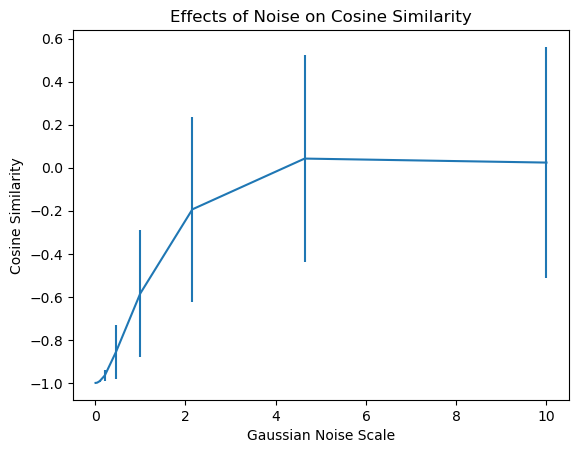

In [20]:
np.random.seed(10)

scale_list = np.logspace(-2,1,10)
mean_cos_sim = np.zeros((10,))
std_cos_sim = np.zeros((10,))
for i_s, scale in enumerate(scale_list):
    cos_sim = np.zeros((100,))
    for i in range(100):
        a1 = np.array([-1,-1,1,1]) + scale*np.random.randn(4) #FGM
        a2 = np.array([1,1,-1,-1]) + scale*np.random.randn(4) #OTSS
        cos_sim[i] = calculate_cosine_similarity(a1,a2)
    mean_cos_sim[i_s] = np.mean(cos_sim)
    std_cos_sim[i_s] = np.std(cos_sim)
    
#plot
plt.errorbar(scale_list,mean_cos_sim,yerr=std_cos_sim)
plt.xlabel("Gaussian Noise Scale")
plt.ylabel("Cosine Similarity")
plt.title("Effects of Noise on Cosine Similarity")

In [44]:
# Sample data creation (assuming data structure)
from scipy.stats import sem

# Function to plot data
def plot_conditions(cond1, cond2, roi):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

    # Filter data based on the selected subject
    roi_data = data[(data['roi'] == roi) & data['in_tgt'] & data['sig'] & data['no_vein']]

    # Normalize Depth
    roi_data['d_norm'] = (roi_data['d'] - roi_data['d'].min()) / (roi_data['d'].max() - roi_data['d'].min())
    
    # Left subplot: Conditions vs. depth
    ax1 = axes[0]
    offset = 0
    for cond in [cond1, cond2]:
        ax1.scatter(roi_data[cond], roi_data['d_norm'], s=1, label=cond, alpha=0.5)
        mean_values = roi_data.groupby('d_bin')[cond].mean()
        std_values = roi_data.groupby('d_bin')[cond].std()
        bins = mean_values.index
        bins_norm = (bins - np.min(bins)) / (np.max(bins) - np.min(bins))
        ax1.errorbar(mean_values, bins_norm+offset, xerr=std_values, label=f'{cond} Mean', fmt='-o', capsize=5)
        offset+=0.01

    ax1.set_xlabel('Condition Values')
    ax1.set_ylabel('Depth (d)')
    ax1.legend()
    ax1.set_title(f'{cond1} and {cond2} vs Depth')

    # Right subplot: Difference between conditions vs. depth
    ax2 = axes[1]
    roi_data['Difference'] = roi_data[cond1] - roi_data[cond2]
    ax2.scatter(roi_data['Difference'], roi_data['d_norm'], s=1, label='Difference', alpha=0.5)
    mean_diff = roi_data.groupby('d_bin')['Difference'].mean()
    std_diff = roi_data.groupby('d_bin')['Difference'].std()
    ax2.errorbar(mean_diff, bins_norm, xerr=std_diff, label='Mean Difference', fmt='-o', capsize=5)

    ax2.set_xlabel('Difference (Condition1 - Condition2)')
    ax2.set_ylabel('Depth (d)')
    ax2.legend()
    ax2.set_title(f'Difference between {cond1} and {cond2} vs Depth')

    plt.tight_layout()
    plt.show()

# Widget for selecting conditions
roi_options = data['roi'].unique()

cond1_dropdown = widgets.Dropdown(
    options=['orth','iso0','iso90','sur','orth_decon','iso0_decon','iso90_decon','sur_decon'],
    value='orth',
    description='Condition 1:',
    disabled=False,
)

cond2_dropdown = widgets.Dropdown(
    options=['orth','iso0','iso90','sur','orth_decon','iso0_decon','iso90_decon','sur_decon'],
    value='iso90',
    description='Condition 2:',
    disabled=False,
)

roi_dropdown = widgets.Dropdown(
    options=roi_options,
    value=roi_options[0],
    description='Subject:',
    disabled=False,
)

# Widget interaction
widgets.interactive(plot_conditions, cond1=cond1_dropdown, cond2=cond2_dropdown, roi=roi_dropdown)

interactive(children=(Dropdown(description='Condition 1:', options=('orth', 'iso0', 'iso90', 'sur', 'orth_deco…

In [45]:
data['orth_decon']

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
7063   NaN
7064   NaN
7065   NaN
7066   NaN
7067   NaN
Name: orth_decon, Length: 7068, dtype: float64